In [1]:
print("Starting Installation...")
!pip install -q monai torchio
print("Installation(s) Complete")

Starting Installation...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 47.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.5/199.5 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 70.6 MB/s eta 0:00:00:00:0100:01
Installation

In [2]:
import os
import shutil
import tarfile
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Spacingd, 
    Orientationd, ScaleIntensityRanged, MapLabelValued,
    RandSpatialCropd, RandFlipd, RandRotate90d, RandRotated, 
    NormalizeIntensityd, ConcatItemsd, ToTensord
)
from monai.data import Dataset, DataLoader, decollate_batch
from monai.networks.nets import AttentionUnet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.networks.utils import one_hot

<frozen importlib._bootstrap_external>:1241: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-04-03 07:33:57.954976: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775201638.163715      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775201638.225990      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
# --- 1. Setup Device ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [4]:
# --- 2. Data Preparation ---
input_tar = '/kaggle/input/brats-2021-task1/BraTS2021_Training_Data.tar'
output_dir = '/kaggle/working/BraTS2021/'

if not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)
    print(f"Extracting {input_tar}...")
    with tarfile.open(input_tar) as tar:
        tar.extractall(path=output_dir)
    print("Extraction Complete")

Extracting /kaggle/input/brats-2021-task1/BraTS2021_Training_Data.tar...
Extraction Complete


In [5]:
# --- 3. Prepare Data List (Splitting Train/Val/Test) ---
patient_ids = sorted(next(os.walk(output_dir))[1])
data_dicts = []
for p_id in patient_ids:
    p_path = os.path.join(output_dir, p_id)
    # Check if files exist to avoid errors
    if os.path.exists(os.path.join(p_path, f"{p_id}_flair.nii.gz")):
        data_dicts.append({
            "flair": os.path.join(p_path, f"{p_id}_flair.nii.gz"),
            "t1": os.path.join(p_path, f"{p_id}_t1.nii.gz"),
            "t1ce": os.path.join(p_path, f"{p_id}_t1ce.nii.gz"),
            "t2": os.path.join(p_path, f"{p_id}_t2.nii.gz"),
            "label": os.path.join(p_path, f"{p_id}_seg.nii.gz"),
        })

# Splitting: 80% Train, 10% Val, 10% Test
num_files = len(data_dicts)
train_files = data_dicts[:int(num_files * 0.8)]
val_files = data_dicts[int(num_files * 0.8):int(num_files * 0.9)]
test_files = data_dicts[int(num_files * 0.9):]

print(f"Total: {num_files} | Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}")

Total: 1251 | Train: 1000 | Val: 125 | Test: 126


In [6]:
# --- 4. Transforms ---
train_transforms = Compose([
    LoadImaged(keys=["flair", "t1", "t1ce", "t2", "label"]),
    EnsureChannelFirstd(keys=["flair", "t1", "t1ce", "t2", "label"]),
    Orientationd(keys=["flair", "t1", "t1ce", "t2", "label"], axcodes="RAS"),
    MapLabelValued(keys="label", orig_labels=[1, 2, 4], target_labels=[0, 1, 2]),
    ConcatItemsd(keys=["flair", "t1", "t1ce", "t2"], name="image"),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    RandSpatialCropd(keys=["image", "label"], roi_size=(128, 128, 64), random_size=False),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=[0, 1, 2]),
    RandRotate90d(keys=["image", "label"], prob=0.5, max_k=3),
    ToTensord(keys=["image", "label"]),
])

val_test_transforms = Compose([
    LoadImaged(keys=["flair", "t1", "t1ce", "t2", "label"]),
    EnsureChannelFirstd(keys=["flair", "t1", "t1ce", "t2", "label"]),
    Orientationd(keys=["flair", "t1", "t1ce", "t2", "label"], axcodes="RAS"),
    MapLabelValued(keys="label", orig_labels=[1, 2, 4], target_labels=[0, 1, 2]),
    ConcatItemsd(keys=["flair", "t1", "t1ce", "t2"], name="image"),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    RandSpatialCropd(keys=["image", "label"], roi_size=(128, 128, 64), random_size=False),
    ToTensord(keys=["image", "label"]),
])

train_ds = Dataset(data=train_files, transform=train_transforms)
val_ds = Dataset(data=val_files, transform=val_test_transforms)
test_ds = Dataset(data=test_files, transform=val_test_transforms)

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=1, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=1, num_workers=2, pin_memory=True)

/usr/local/lib/python3.11/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


In [7]:
# --- 5. Model, Loss, Optimizer ---
# Using FlexibleUNet with EfficientNet-B7 backbone
# AttentionUnet is natively 3D and supports attention gates
model = AttentionUnet(
    spatial_dims=3,
    in_channels=4,
    out_channels=3,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
).to(device)

loss_function = DiceCELoss(to_onehot_y=True, softmax=True)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
dice_metric = DiceMetric(include_background=False, reduction="mean")
scaler = torch.amp.GradScaler('cuda')

In [8]:
# --- 6. Training Loop ---
epochs = 10
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0
    for batch_data in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
        inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)
        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            loss = loss_function(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        epoch_train_loss += loss.item()
    
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for val_data in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
            val_inputs, val_labels = val_data["image"].to(device), val_data["label"].to(device)
            with torch.amp.autocast('cuda'):
                val_outputs = model(val_inputs)
                # Validation loss using the same loss function
                v_loss = loss_function(val_outputs, val_labels)
            
            epoch_val_loss += v_loss.item()
            val_labels_onehot = one_hot(val_labels, num_classes=3)
            dice_metric(y_pred=val_outputs, y=val_labels_onehot)
        
        avg_val_loss = epoch_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        
        metric = dice_metric.aggregate().item()
        dice_metric.reset()
        print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Dice: {metric:.4f}")

Epoch 1/10 [Val]: 100%|██████████| 125/125 [01:51<00:00,  1.13it/s]


Epoch 1: Train Loss: 1.4868 | Val Loss: 1.3320 | Val Dice: 0.0407


Epoch 2/10 [Val]: 100%|██████████| 125/125 [01:50<00:00,  1.13it/s]


Epoch 2: Train Loss: 1.1802 | Val Loss: 1.0883 | Val Dice: 0.0329


Epoch 3/10 [Val]: 100%|██████████| 125/125 [01:50<00:00,  1.13it/s]


...

Epoch 8: Train Loss: 0.4446 | Val Loss: 0.5300 | Val Dice: 0.0384


Epoch 9/10 [Val]: 100%|██████████| 125/125 [01:53<00:00,  1.10it/s]


Epoch 9: Train Loss: 0.4001 | Val Loss: 0.4942 | Val Dice: 0.0318


Epoch 10/10 [Val]: 100%|██████████| 125/125 [01:50<00:00,  1.13it/s]

Epoch 10: Train Loss: 0.3642 | Val Loss: 0.4814 | Val Dice: 0.0370


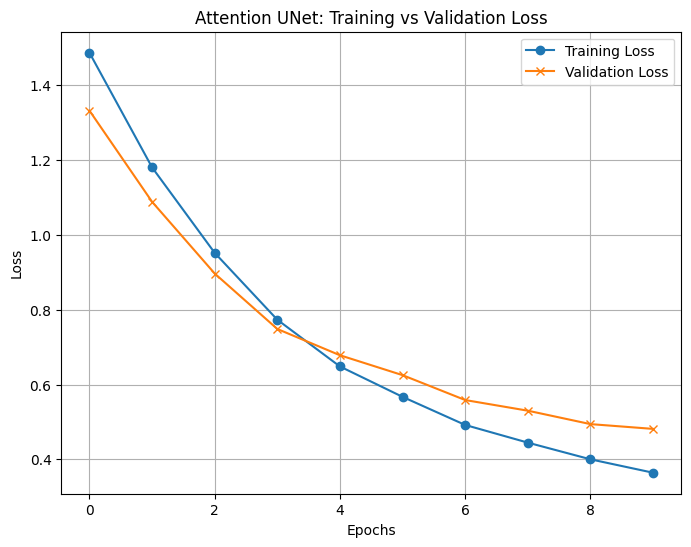

In [9]:
# --- 7. Plotting Loss Curves ---
plt.figure(figsize=(8, 6))
plt.plot(train_losses, label='Training Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='x')
plt.title('Attention UNet: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# --- 8. Final Test Evaluation ---
print("\n--- Evaluation on Test Data ---")
model.eval()
test_loss_sum = 0
dice_metric.reset()

with torch.no_grad():
    for test_data in tqdm(test_loader, desc="Testing"):
        test_inputs, test_labels = test_data["image"].to(device), test_data["label"].to(device)
        with torch.amp.autocast('cuda'):
            test_outputs = model(test_inputs)
            t_loss = loss_function(test_outputs, test_labels)
        
        test_loss_sum += t_loss.item()
        test_labels_onehot = one_hot(test_labels, num_classes=3)
        dice_metric(y_pred=test_outputs, y=test_labels_onehot)

avg_test_loss = test_loss_sum / len(test_loader)
avg_test_dice = dice_metric.aggregate().item()

print(f"\nFinal Test Results:")
print(f"Average Test Loss: {avg_test_loss:.4f}")
print(f"Average Test Dice: {avg_test_dice:.4f}")


--- Evaluation on Test Data ---


Testing: 100%|██████████| 126/126 [02:13<00:00,  1.06s/it]


Final Test Results:
Average Test Loss: 0.3602
Average Test Dice: 0.0391


Validation Sample #1


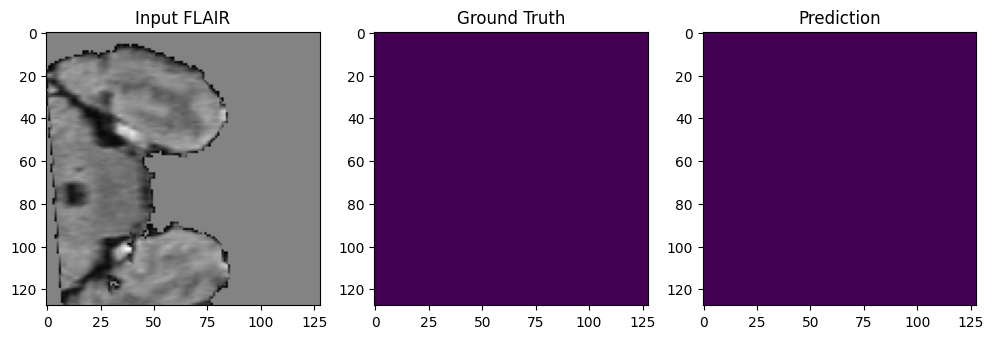

Validation Sample #2


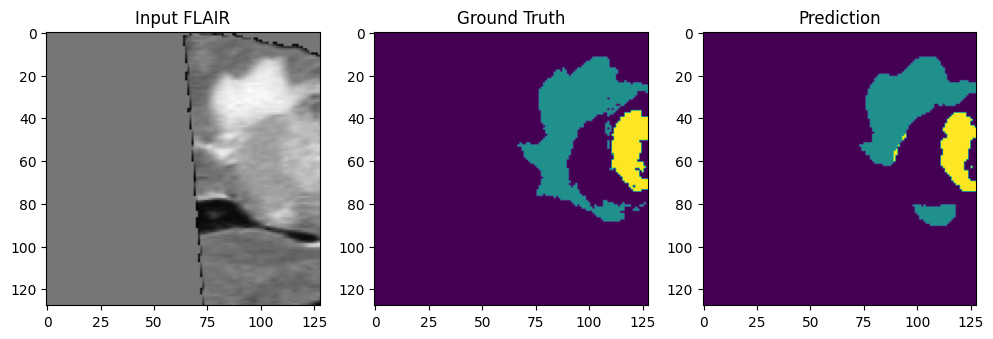

Validation Sample #3


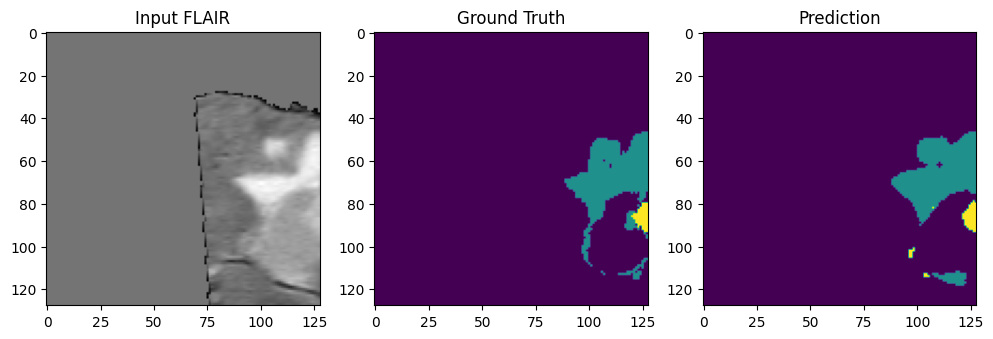

Validation Sample #4


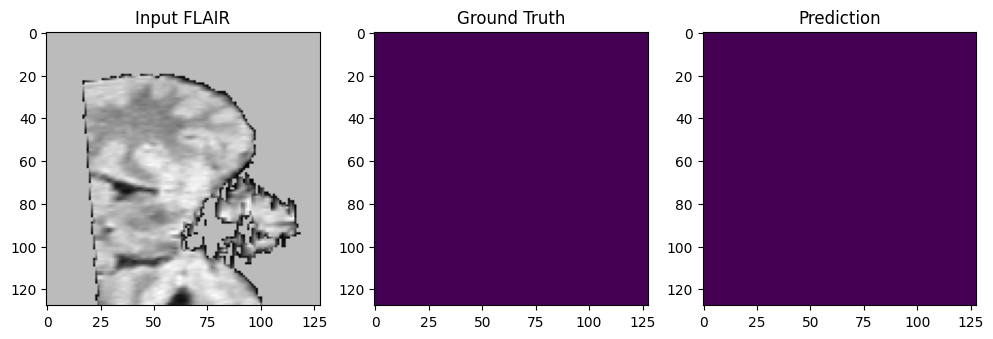

Validation Sample #5


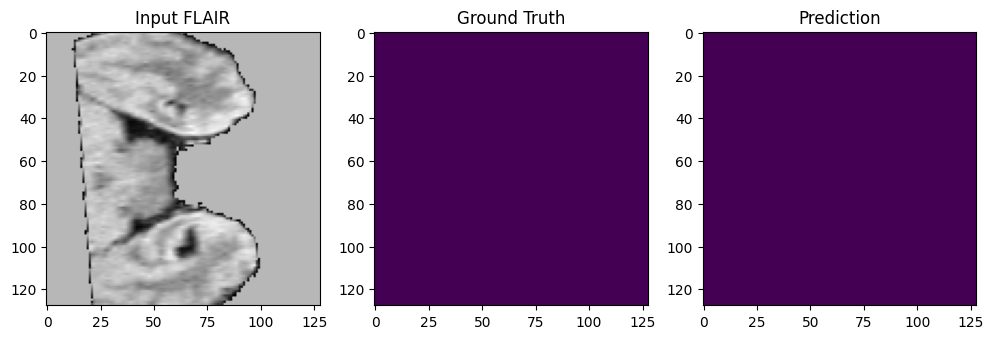

In [11]:
# --- 9. Visualization ---
def visualize_result(data_batch):
    model.eval()
    with torch.no_grad():
        test_input = data_batch["image"][0:1].to(device)
        test_output = model(test_input)
        test_output = torch.argmax(test_output, dim=1).detach().cpu()[0]
    
    img = data_batch["image"][0, 0] # FLAIR channel
    lab = data_batch["label"][0, 0]
    
    slice_idx = img.shape[-1] // 2
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1); plt.title("Input FLAIR"); plt.imshow(img[:, :, slice_idx], cmap="gray")
    plt.subplot(1, 3, 2); plt.title("Ground Truth"); plt.imshow(lab[:, :, slice_idx])
    plt.subplot(1, 3, 3); plt.title("Prediction"); plt.imshow(test_output[:, :, slice_idx])
    plt.show()

# Visualize one sample from validation
for i in range(5):
    print(f"Validation Sample #{i+1}")
    visualize_result(next(iter(val_loader)))

In [16]:
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    Resized,
    ScaleIntensityRanged,
    ToTensord,
)

In [17]:
# --- 1. Settings ---
root_dir = "/kaggle/working/monai_data"
os.makedirs(root_dir, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Tasks to import: Task01 (Brain), Task04 (Hippocampus), Task09 (Spleen)
tasks = ["Task01_BrainTumour", "Task04_Hippocampus", "Task09_Spleen"]

In [18]:
# --- 2. Shared Evaluation Transform ---
# Note: We resize to match your model's expected input (128, 128, 64)
eval_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Resized(keys=["image", "label"], spatial_size=(128, 128, 64), mode=("trilinear", "nearest")),
    ScaleIntensityRanged(keys="image", a_min=0, a_max=255, b_min=0.0, b_max=1.0, clip=True),
    ToTensord(keys=["image", "label"]),
])

In [19]:
from monai.apps import DecathlonDataset
from torch.utils.data import Subset

# --- 3. The Multi-Dataset Test Loop ---
dice_metric = DiceMetric(include_background=False, reduction="mean")
model.eval()

print("--- Starting Auto-Import Evaluation ---")

import shutil
if os.path.exists("/kaggle/working/BraTS2021"):
    shutil.rmtree("/kaggle/working/BraTS2021")

for task_name in tasks:
    print(f"\nProcessing {task_name}...")

    # Define the specific data directory
    root_dir = "/kaggle/working/monai_data"
    
    # Safely clear out ONLY the data folder if it exists
    if os.path.exists(root_dir):
        print(f"Clearing previous data in {root_dir}...")
        shutil.rmtree(root_dir)
    
    # Recreate the folder for the new task
    os.makedirs(root_dir, exist_ok=True)
    
    # IMPORT DIRECTLY FROM MONAI
    # download=True handles everything. cache_rate=0.0 keeps RAM safe.
    full_ds = DecathlonDataset(
        root_dir=root_dir, 
        task=task_name, 
        section="training", 
        download=True, 
        transform=eval_transforms,
        cache_rate=0.0 
    )

    # Sample exactly 20%
    num_samples = max(1, int(len(full_ds) * 0.2))
    indices = torch.randperm(len(full_ds))[:num_samples]
    sampled_ds = Subset(full_ds, indices)
    
    test_loader = DataLoader(sampled_ds, batch_size=1, num_workers=2)

    # Evaluation loop
    with torch.no_grad():
        for batch_data in tqdm(test_loader, desc=f"Testing {task_name}"):
            inputs = batch_data["image"].to(device)
            labels = batch_data["label"].to(device)

            # CHANNEL MATCHING HACK:
            # Your BraTS model expects 4 channels. Most MSD tasks only have 1.
            # We repeat the single channel 4 times so the model can process it.
            if inputs.shape[1] == 1:
                inputs = inputs.repeat(1, 4, 1, 1, 1)
            elif inputs.shape[1] > 4: # Task01 has 4, but some might have more
                inputs = inputs[:, :4, ...]

            with torch.cuda.amp.autocast():
                outputs = model(inputs)
            
            # Simple Dice calculation (ignoring multi-class complexities for speed)
            dice_metric(y_pred=outputs, y=labels)

        final_score = dice_metric.aggregate().item()
        dice_metric.reset()
        print(f">> {task_name} Average Dice: {final_score:.4f}")

--- Starting Auto-Import Evaluation ---

Processing Task01_BrainTumour...
Clearing previous data in /kaggle/working/monai_data...


Task01_BrainTumour.tar: 7.09GB [03:08, 40.4MB/s]                               


2026-04-03 10:37:36,382 - INFO - Downloaded: /kaggle/working/monai_data/Task01_BrainTumour.tar
2026-04-03 10:37:50,323 - INFO - Verified 'Task01_BrainTumour.tar', md5: 240a19d752f0d9e9101544901065d872.
2026-04-03 10:37:50,323 - INFO - Writing into directory: /kaggle/working/monai_data.


Testing Task01_BrainTumour:   0%|          | 0/77 [00:00<?, ?it/s]/tmp/ipykernel_37/4197929369.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Testing Task01_BrainTumour: 100%|██████████| 77/77 [00:58<00:00,  1.32it/s]


>> Task01_BrainTumour Average Dice: 0.0092

Processing Task04_Hippocampus...
Clearing previous data in /kaggle/working/monai_data...


...

>> Task04_Hippocampus Average Dice: 0.0506

Processing Task09_Spleen...
Clearing previous data in /kaggle/working/monai_data...


Task09_Spleen.tar: 1.50GB [00:36, 44.3MB/s]                               


2026-04-03 10:39:49,952 - INFO - Downloaded: /kaggle/working/monai_data/Task09_Spleen.tar
2026-04-03 10:39:52,823 - INFO - Verified 'Task09_Spleen.tar', md5: 410d4a301da4e5b2f6f86ec3ddba524e.
2026-04-03 10:39:52,824 - INFO - Writing into directory: /kaggle/working/monai_data.


Testing Task09_Spleen: 100%|██████████| 6/6 [00:04<00:00,  1.46it/s]

>> Task09_Spleen Average Dice: 0.0116
